# 04. Эксперименты

В CP1 планка была MAE ≈ 300 $ — её задал KNN на пяти исходных признаках.
Здесь мы проверяем шесть гипотез и смотрим, что из них действительно работает.

Сначала сравниваем модели на одинаковых признаках, потом
подбираем признаки на одной модели, и только затем — гиперпараметры.

Тестовая выборка в этом ноутбуке не используется вообще. Все сравнения —
на валидации. Тест увидит только финальная модель в ноутбуке 05... так удобнее просто

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd

from src.config import TARGET
from src.models.evaluate import metrics_table
from src.models.experiments import get_splits, load_prepared
from src.models.train import build_model_zoo, build_preprocessor, run_experiment
from src.utils.seed import set_seed
from src.utils.warnings import silence_blas_warnings

silence_blas_warnings()
set_seed()
pd.set_option("display.width", 200)

/Users/dianochka_l/Desktop/ProjectML/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
df = load_prepared()
train, val, test = get_splits(df)
print(f"{df.shape[1]}")

21:23:55 | INFO    | src.data.split | train  62914 строк (63.5%) | средняя цена 1518
21:23:55 | INFO    | src.data.split | val    16223 строк (16.4%) | средняя цена 1509
21:23:55 | INFO    | src.data.split | test   19888 строк (20.1%) | средняя цена 1504
21:23:55 | INFO    | src.data.split | Проверка утечки: {'shared_groups': 0, 'shared_dedup_keys': 0}
73


## Эксперимент 5. Какая модель лучше?

Одиннадцать моделей на одном и том же наборе признаков таблица + target
encoding города и штата, без текста. Сравнение честное — препроцессор один
и тот же, отличается только модель

Запуск занимает около четырёх минут (дольше всего обучается стекинг),
поэтому здесь читаем сохранённый результат прогона
`python -m src.models.experiments --stage models`

In [4]:
import json

from src.config import RUNS_DIR
zoo_run = json.loads((RUNS_DIR / "cp2_model_zoo.json").read_text(encoding="utf-8"))
metrics_table(zoo_run["metrics"])

,mae,rmse,mape,r2,median_ae,fit_seconds
extra_trees,190.221,314.757,13.304,0.826,121.451,12.7
voting_lgbm_xgb_rf,192.668,308.245,13.338,0.833,126.606,24.6
xgboost,193.760,308.625,13.322,0.833,129.033,1.6
stacking_lgbm_rf_ridge,195.300,309.819,13.613,0.831,129.602,143.3
lightgbm,196.583,309.693,13.605,0.831,132.552,4.2
random_forest,201.152,325.172,14.048,0.814,131.347,19.6
hist_gb,208.630,323.582,14.493,0.816,142.695,4.0
catboost,217.439,340.609,15.036,0.796,147.202,2.0
decision_tree,254.729,408.710,17.491,0.706,165.269,1.1
ridge,268.227,412.380,18.907,0.701,186.666,0.4


1. **Ансамбли деревьев отрываются от всего остального** ExtraTrees (190 $) и
   XGBoost (194 $) против 268 $ у линейных моделей. Цена аренды нелинейно
   зависит от признаков, и линейная комбинация тут бессильна.

2. **ExtraTrees лучший по MAE, XGBoost — по RMSE и R2**
   ExtraTrees точнее в типичных случаях, XGBoost реже допускает крупные промахи.
   Основная метрика у нас MAE, но разрыв в 3 доллара — в пределах шума,
   так что окончательный выбор отложим.

3. **Ансамбли не превзошли лучшую одиночную модель** Voting дал 193 $,
   стекинг — 195 $, оба хуже ExtraTrees. Базовые модели сильно коррелируют: усреднять почти одинаковые предсказания
   бессмысленно. Зато стекинг обучался 143 секунды против 13 у ExtraTrees —
   в двадцать раз дороже без выигрыша

4. **KNN опустился на последнее место**
   На 116 признаках расстояние размывается

## 6-8. Что дают признаки и преобразование таргета

Теперь фиксируем модель (LightGBM) и меняем набор признаков.
Каждая строка добавляет к предыдущей ровно одно изменение — так видно
вклад каждого шага по отдельности

In [5]:
features_run = json.loads((RUNS_DIR / "cp2_feature_sets.json").read_text(encoding="utf-8"))
table = metrics_table(features_run["metrics"])
table["прирост MAE, $"] = (
    table["mae"].iloc[0] - table["mae"]
).round(1)
table

,mae,rmse,mape,r2,median_ae,fit_seconds,"прирост MAE, $"
с текстом + log(price),177.589,297.087,11.736,0.845,114.385,17.7,0.0
с текстом (TF-IDF+SVD),181.317,295.015,12.514,0.847,120.336,18.8,-3.7
с target encoding,196.583,309.693,13.605,0.831,132.552,4.2,-19.0
без target encoding,202.961,322.335,14.060,0.817,137.368,4.2,-25.4


**Разбор по шагам:**

| Шаг | MAE, $ | Что изменилось |
|---|---|---|
| без target encoding | 203.0 | город в модель не попадает вообще |
| + target encoding | 196.6 | город и штат закодированы средней ценой |
| + текст (TF-IDF → SVD) | 181.3 | добавились 100 компонент из текста объявления |
| + обучение на log(price) | 177.6 | таргет логарифмирован |

**Самым полезным оказался текст** — минус 15 долларов, больше, чем все
остальные шаги. Это логично: в описании указано то, чего нет в структурных
полях — состояние ремонта, близость к центру, тип дома.

**Target encoding дал 6 долларов.** Немного, но важно, что он вообще
работает: наивное кодирование средней ценой было бы утечкой, а
cross-fitting из `TargetEncoder` считает статистики по фолдам без текущей
строки. Подробности — в `src/data/encoders.py`.

**Лог-таргет дал 4 доллара по MAE, но заметно больше по MAPE** — 11.7%
против 12.5%. Обучение на логарифме оптимизирует относительную ошибку,
и сильнее всего это помогает дешёвому сегменту, где 200 долларов промаха
critичны.

## 9. Финалисты на лучшем наборе признаков

В 5 модели сравнивались без текста, а текст
оказался самой полезной группой признаков. Порядок моделей на другом наборе
признаков может измениться, поэтому лидеров надо пересравнить

In [6]:
finalists_run = json.loads((RUNS_DIR / "cp2_finalists.json").read_text(encoding="utf-8"))
metrics_table(finalists_run["metrics"])

,mae,rmse,mape,r2,median_ae,fit_seconds
xgboost,172.478,293.192,11.408,0.849,108.401,18.2
voting_lgbm_xgb_rf,176.345,300.108,11.703,0.842,110.841,171.6
extra_trees,176.734,311.447,11.883,0.829,107.868,48.5
lightgbm,177.589,297.087,11.736,0.845,114.385,19.8
random_forest,192.160,326.345,12.925,0.813,120.557,166.4


На признаках без текста лидировал
ExtraTrees, с текстом вперёд вышел XGBoost
Объяснение простое — сто компонент SVD это плотные вещественные признаки
со слабым индивидуальным сигналом. Бустинг умеет набирать качество
из множества слабых признаков, случайный лес со случайными разбиениями —
хуже.

XGBoost к тому же обучается за 18 секунд против 49 у ExtraTrees
и 172 у голосующего ансамбля.

**Кандидаты на подбор гиперпараметров XGBoost и ExtraTrees** — два разных
по устройству семейства с близким качеством.

## 10. Снижение размерности

После препроцессинга 116 признаков. Для бустингов это нормально, а вот KNN
в CP1 заметно просел при переходе с 5 признаков на 60

In [7]:
dimred_run = json.loads((RUNS_DIR / "cp2_dimred.json").read_text(encoding="utf-8"))
metrics_table(dimred_run["metrics"])

,mae,rmse,mape,r2,median_ae,fit_seconds
knn_pca_10,274.628,421.815,19.252,0.687,185.9,NaN
knn_pca_20,274.665,422.305,19.092,0.686,184.6,NaN
knn_pca_80,276.270,432.847,19.117,0.671,182.2,NaN
knn_pca_40,276.813,428.794,19.224,0.677,184.3,NaN
knn_all_features,279.211,434.206,19.609,0.669,192.6,0.4
knn_pca_5,338.026,497.575,24.552,0.565,240.1,NaN
knn_pca_2,511.528,724.879,38.425,0.076,385.3,NaN


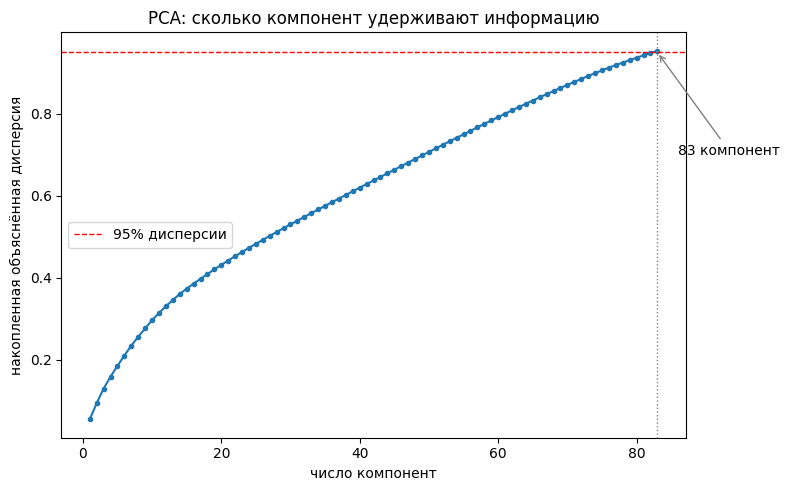

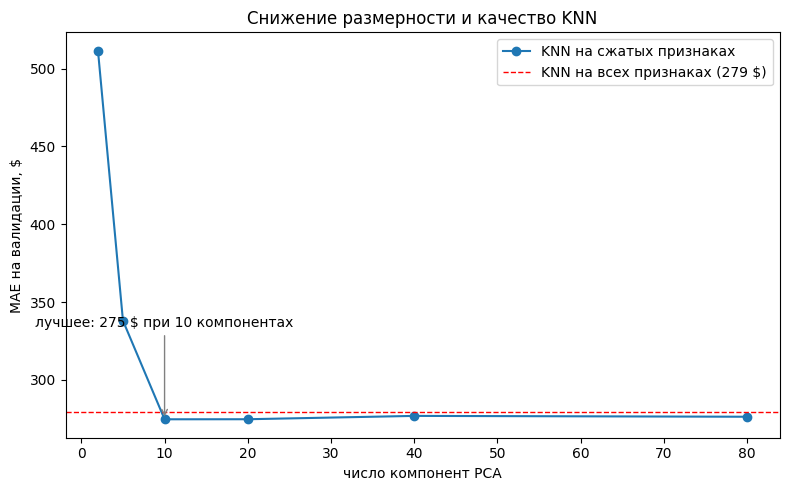

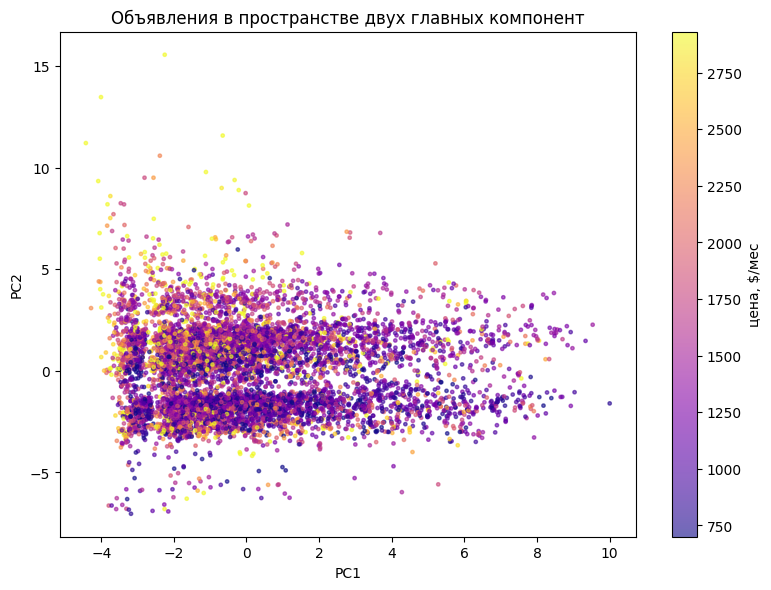

In [8]:
from IPython.display import Image, display

display(Image("../reports/figures/pca_explained_variance.png"))
display(Image("../reports/figures/dimred_knn_curve.png"))
display(Image("../reports/figures/pca_scatter.png"))

**Результат** KNN на всех признаках даёт 279 $, на 10 компонентах PCA — 275 $. Выигрыш есть, но маленький,
и отставание от бустинга (172 $) он не сокращает

Кривая имеет понятную форму... на 2-5 компонентах качество ужасное, на 10-20 оптимум, дальше плато — лишние компоненты
не мешают, но и не помогают.

## Итоги экспериментов

| # | Гипотеза | Подтвердилась? | Эффект |
|---|---|---|---|
| 1 | Бустинг обыграет KNN | да | 279 → 172 $ |
| 2 | Target encoding города даст наибольший прирост | нет | всего 6 $ |
| 3 | log(price) уменьшит ошибку на дорогом сегменте | да | MAPE 12.5% → 11.7% |
| 4 | Текст объявления даст прирост | да, сильнее всего | 15 $ |
| 5 | Снижение размерности вернёт KNN преимущество | почти нет | 4 $, расклад не меняет |
| 6 | Ансамбль обыграет одиночные модели | нет | хуже лучшей модели, дороже в 10 раз |

**Лучшая конфигурация на валидации XGBoost + target encoding + текст +
обучение на log(price), MAE = 172.5 $**

Против baseline это улучшение в 1.74 раза.
Дальше — подбор гиперпараметров и финальная модель в ноутбуке 05